#Data Clean

In [1]:
!pip install lingua-language-detector
!pip install deep_translator
!pip install vaderSentiment

import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

from deep_translator                 import GoogleTranslator
from lingua                          import Language, LanguageDetectorBuilder
from vaderSentiment.vaderSentiment   import SentimentIntensityAnalyzer
from collections import Counter

from google.colab import files, drive, userdata

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/ddds-cohort-21/Projects/Capstone/Data/chat_metrics_20260730_062950.xlsx'

dfs = pd.read_excel(file_path, sheet_name=None)
df = dfs['Raw Data']
feedback = dfs['User Feedback']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
dfs = pd.read_excel(file_path, sheet_name=None)
df = dfs['Raw Data']
feedback = dfs['User Feedback']

In [3]:
#Raw Data
#Drop excess columns
df.drop(columns=['user_id', 'correlation_id', 'hour', 'date', 'secondary_category', 'step_summaries_count'], inplace=True)

#Convert from UTC to Mountain Time (Albuquerque)
df['timestamp'] = df['timestamp'].dt.tz_localize('UTC').dt.tz_convert('America/Denver')

#Update day of week to match local time
df['day_of_week'] = df['timestamp'].dt.day_name()

#Fill primary category nulls
df.loc[814, 'primary_category']= 'sunport_amenities'
df.loc[816, 'primary_category']= 'navigation'
df.loc[817, 'primary_category']= 'navigation'
df.loc[818, 'primary_category']= 'airline_logistics'

#Feedback
#Drop null star rating
feedback.drop([147, 262, 309, 311, 761], inplace=True)

#Drop unneccesary columns
feedback.drop(columns=['timestamp', 'ip_address', 'feedback_text'], inplace=True)

#Drop Duplicates
feedback = feedback.drop_duplicates()

#Merge
df = df.merge(feedback[['chat_id', 'star_rating']], on='chat_id', how='left')

#Emojis
emoji_pattern = re.compile(
    '['
    '\U0001F600-\U0001F64F'  # emoticons
    '\U0001F300-\U0001F5FF'  # symbols & pictographs
    '\U0001F680-\U0001F6FF'  # transport & map symbols
    '\U0001F1E0-\U0001F1FF'  # flags
    ']+',
    flags=re.UNICODE
)

#Find questions with emojis
emoji_questions = df[df['question'].astype(str).apply(lambda x: bool(emoji_pattern.search(x)))]

#Replace emojies with Okay
df['question'] = df['question'].replace('👍', 'Okay')

#Find different languages
detector = (LanguageDetectorBuilder.from_all_languages().build())

def detect_language(text, threshold=0.55):
  if not isinstance(text, str) or text.strip() == '':
    return 'ENGLISH'

  #Get confidence values for all languages
  confidence_values = detector.compute_language_confidence_values(text)

  #Check if highest matched meets your threshold
  if confidence_values and confidence_values[0].value > threshold:
    return confidence_values[0].language.name #Added name here

  return 'ENGLISH'

df['question_language'] = df['question'].apply(detect_language)
df['answer_language'] = df['answer'].apply(detect_language)

#Replace false positives
df['answer_language'] = df['answer_language'].replace(['LATIN', 'YORUBA', 'ESPERANTO'], 'ENGLISH')

#Translate
translator = GoogleTranslator(source='auto', target='en')

def translate_to_english(text):
  if not isinstance(text, str) or text.strip() == '':
    return text

  try:
    return translator.translate(text)
  except Exception:
    return text

#Translate questions
df['question_en'] = df['question']

mask = df['question_language'] != 'ENGLISH'

df.loc[mask, 'question_en'] = (df.loc[mask, 'question'].apply(translate_to_english))

#Translate answers
df['answer_en'] = df['answer']

mask = df['answer_language'] != 'ENGLISH'

df.loc[mask, 'answer_en'] = (df.loc[mask, 'answer'].apply(translate_to_english))

df['question'] = df['question_en']
df['answer'] = df['answer_en']

#Clean up and drop
df.drop(columns=['chat_id', 'question_language', 'answer_language', 'question_en', 'answer_en'], inplace=True)

In [20]:
#Aggregate
def round_to_half(x):
  return round(x * 2) / 2

df_clean = df.groupby('session_id').agg(
    timestamp = ('timestamp', 'first'),
    day_of_week = ('day_of_week', lambda x: x.mode().loc[0] if not x.mode().empty else None),
    processing_time_seconds = ('processing_time_seconds', 'sum'),
    total_tokens = ('total_tokens', 'sum'),
    input_tokens = ('input_tokens', 'sum'),
    output_tokens = ('output_tokens', 'sum'),
    model_calls = ('model_calls', 'sum'),
    tool_calls_count = ('tool_calls_count', 'sum'),
    question_length = ('question_length', 'sum'),
    answer_length = ('answer_length', 'sum'),
    primary_category = ('primary_category', lambda x: ', '.join(x.dropna().unique())),
    selected_agent = ('selected_agent', lambda x: ', '.join(x.dropna().unique())),
    has_geolocation = ('has_geolocation', 'any'),
    star_rating = ('star_rating', lambda x: round_to_half(x.mean()) if pd.notna(x.mean()) else np.nan),
    question = ('question', lambda x: ' '.join(x.dropna())),
    answer = ('answer', lambda x: ' '.join(x.dropna()))
).reset_index()

#Binary Satisfaction
df_clean['satisfaction'] = (df_clean['star_rating'] >= 4).astype(int)

df_clean['satisfaction'].value_counts(normalize=True)

#Set target
target = 'satisfaction'

#Multi-Label Binary Encoding
#Primary Categories
categories = [
  'greetings',
  'sunport_amenities',
  'navigation',
  'airline_logistics',
  'general_info'
]

for category in categories:
  df_clean[f'primary_category_{category}'] = (
    df_clean['primary_category']
    .str.contains(category, regex=False, na=False)
    .astype('int8')
  )

#Selected Agent
agents = [
  'reporter',
  'planner',
  'location',
  'location_fallback_to_reporter',
  'broad_search_synthesis',
  'broad_search_passthrough'
]

for agent in agents:
  df_clean[f'selected_agent{agent}'] = (
    df_clean['selected_agent']
    .str.contains(agent, regex=False, na=False)
    .astype('int8')
  )

#Datetime
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

df_clean['year'] = df_clean['timestamp'].dt.year
df_clean['month'] = df_clean['timestamp'].dt.month
df_clean['day'] = df_clean['timestamp'].dt.day
df_clean['hour'] = df_clean['timestamp'].dt.hour

df_clean.drop(columns='timestamp', inplace=True)

#Cyclical Encoding
#Days of the Week
days = {
  'Monday':0,
  'Tuesday':1,
  'Wednesday':2,
  'Thursday':3,
  'Friday':4,
  'Saturday':5,
  'Sunday':6
}

df_clean['day_num'] = df_clean['day_of_week'].map(days)

df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['day_num'] / 7)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['day_num'] / 7)

#Hour
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

#Month
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['month'] / 12)
df_clean['month_cos'] = np.sin(2 * np.pi * df_clean['month'] / 12)

#Term Frequency-Inverse Document Frequency
#Question TF-IDF
tfidf_question = TfidfVectorizer(max_features=500, stop_words='english')

question_tfidf = tfidf_question.fit_transform(df_clean['question'].fillna(''))

question_features = tfidf_question.get_feature_names_out()

#Weight of each word across all questions
scores = np.asarray(question_tfidf.sum(axis=0)).flatten()

top_words = pd.DataFrame({'word': question_features, 'tfidf_score':scores}).sort_values('tfidf_score', ascending=False)

#Answer TF-IDF
tfidf_answer = TfidfVectorizer(max_features=500, stop_words='english')

answer_tfidf = tfidf_answer.fit_transform(df_clean['answer'].fillna(''))

answer_features = tfidf_answer.get_feature_names_out()

#Weight of each word across all questions
scores = np.asarray(answer_tfidf.sum(axis=0)).flatten()

top_words = pd.DataFrame({'word': answer_features, 'tfidf_score':scores}).sort_values('tfidf_score', ascending=False)

#Sentiment Analysis
#Create analyzer
analyzer = SentimentIntensityAnalyzer()

#Create function
def get_sentiment(text):
  if pd.isna(text) or str(text).strip() == '':
    return 0

  return analyzer.polarity_scores(str(text))['compound']

#Question Sentiment
df_clean['question_sentiment'] = df_clean['question'].apply(get_sentiment)

#Answer Sentiment
df_clean['answer_sentiment'] = df_clean['answer'].apply(get_sentiment)

#Create sentiment score categories
def sentiment_category(score):
  if score >= 0.75:
    return 'positive'
  elif score <= 0.25:
    return 'negative'
  else:
    return 'neutral'

df_clean['question_sentiment_category'] = (df_clean['question_sentiment'].apply(sentiment_category))
df_clean['answer_sentiment_category'] = (df_clean['answer_sentiment'].apply(sentiment_category))

In [33]:
#Make a copy
super_clean = df_clean.copy()

#Keep sessions with star_rating only
super_clean.dropna(subset=['star_rating', 'selected_agent', 'primary_category'], inplace=True)

#Data Exploration

##Repeated

In [6]:
question_en = ('question', lambda x: ' '.join(x.dropna()))
answer_en = ('answer', lambda x: ' '.join(x.dropna()))

#Questions
question_counts = (
    df['question']
    .dropna()
    .str.strip()
    .str.lower()
    .value_counts()
)

question_counts.head(20)

,count
question,
how do i find baggage claim?,406
how do i get to gate a7?,379
how do i get to the rental car area?,370
where is the nearest restroom?,367
where is gate b12?,358
how do i get from terminal 1 to terminal 2?,353
how do i get to security checkpoint?,342
where is the nearest exit?,334
where can i catch a taxi?,313


In [7]:
#Answers
answer_counts = (
    df['answer']
    .dropna()
    .str.strip()
    .str.lower()
    .value_counts()
)

answer_counts.head(20)

,count
answer,
"to reach the rental car area, exit through door 4 on the lower level and look for the rental car shuttle stop. shuttles run every 5-10 minutes to the consolidated rental car facility. most major rental companies are located there.",1156
baggage claim is located on the lower level of the terminal. take the escalator or elevator down one floor. follow the signs for 'baggage claim' - it's about a 2 minute walk from here. your carousel number will be displayed on the monitors.,1123
"to get to gate a7, head through the main terminal corridor past the security checkpoint. continue straight for about 200 meters, then look for signs directing you to concourse a. gate a7 will be on your right, approximately 3 minutes walk from here.",1117
the nearest restroom is located just past the southwest airlines check-in counter. walk about 50 meters towards the food court and you'll see the restroom signs on your left. there are also family restrooms available in that area.,1081
"the parking garage is accessible from the main terminal exit. head towards the 'ground transportation' signs and take the covered walkway to the parking structure. short-term parking is on levels 1-3, long-term parking is on levels 4-6.",1071
i found some information but couldn't fully answer for your question. for assistance:\n\n- **abq sunport website**: abqsunport.com\n- **airport info desk**: (505) 244-7700\n- **visit the information desk** in the great hall for in-person help,480
i found some information but couldn't fully answer for your flight question. for the most accurate and up-to-date information:\n\n- **flight status**: check abqsunport.com/flights or your airline's app\n- **airline policies**: contact your airline directly\n- **airport info desk**: (505) 244-7700,81
"i cannot provide information on tsa wait times as no sunport amenity data was retrieved. please specify if you are asking about shops, parking, transportation, or terminal navigation (gates, baggage claim, restrooms, etc.).",49
the tsa checkpoint hours of operation are generally from **4:00 a.m. to 11:45 p.m.,49


###Sessions

In [8]:
repeated_answers = (
    df.groupby('session_id')['answer']
    .apply(lambda x: x.dropna().str.lower().duplicated().sum())
    .reset_index(name='Repeated Answers')
)

repeated_answers.sort_values(
    'Repeated Answers',
    ascending=False
).head(20)

,session_id,Repeated Answers
2730,63adeb7b-825b-48e6-8134-94230b1040fc,22
4557,a7837089-0e61-4176-b501-b20ba43df553,21
997,2421b36b-dd98-4cbd-8c19-27f74aa6e3c0,21
46,02075f3e-ef88-493c-b94b-93d47fedc06f,21
1613,3a2142d2-f448-4fb7-89e7-94b53eb10058,20
1035,2587ac32-16f0-4d37-bc41-7358e968b5ba,20
680,17790ce5-2706-4761-879d-bb694fb6b088,20
1615,3a48b4e1-117f-412f-b8a0-6d4f397f9af0,20
1854,433022c0-dd2e-4f17-a954-9a4c0d1d5b25,20
1631,3ac49462-cec9-43c9-9823-51d93dd10a28,20


##Minor Differences

In [9]:
questions = df['question'].dropna().drop_duplicates()

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2)
)

question_matrix = vectorizer.fit_transform(questions)

similarity_matrix = cosine_similarity(question_matrix)

similar_pairs = []

for i in range(len(questions)):
    for j in range(i + 1, len(questions)):

        similarity = similarity_matrix[i, j]

        if similarity >= 0.80: #Explore
            similar_pairs.append({
                'Question 1': questions.iloc[i],
                'Question 2': questions.iloc[j],
                'Similarity': similarity
            })

similar_questions = pd.DataFrame(similar_pairs)

similar_questions.sort_values(
    'Similarity',
    ascending=False
).head(20)

,Question 1,Question 2,Similarity
1052,Fly side pass,How do I get a fly pass?,1.0
1051,Fly side pass,How do I get the fly side pass?,1.0
2192,When does TSA open?,when does tsa open,1.0
2189,When does TSA open?,When does tsa open?,1.0
1716,Flights coming in from Denver,Flights coming from Denver,1.0
1732,Where is the meditation room,Where is meditation room,1.0
1731,Where is the meditation room,Where is the meditation room?,1.0
1730,Is there a prayer room here,Prayer room,1.0
1729,Is there a prayer room here,Is there a prayer room?,1.0
1753,How do I get a fly pass?,How do we get a Fly By Pass?,1.0


##Common

In [10]:
#Question Words
text = ' '.join(
    df['question']
    .dropna()
    .astype(str)
    .str.lower()
)

words = re.findall(r'\b[a-z]+\b', text)

word_counts = Counter(words)

word_counts.most_common(30)

[('i', 6850),
 ('the', 6505),
 ('is', 5175),
 ('to', 4464),
 ('where', 4071),
 ('how', 3791),
 ('do', 3748),
 ('what', 2826),
 ('can', 2691),
 ('a', 2618),
 ('get', 2436),
 ('there', 2269),
 ('are', 2083),
 ('flight', 1824),
 ('my', 1819),
 ('in', 1644),
 ('airport', 1581),
 ('gate', 1419),
 ('tsa', 1221),
 ('for', 1196),
 ('terminal', 1156),
 ('time', 1155),
 ('at', 1087),
 ('from', 1014),
 ('you', 930),
 ('nearest', 927),
 ('security', 925),
 ('parking', 826),
 ('on', 820),
 ('have', 811)]

In [11]:
#Question Phrases
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(2, 2),
    max_features=50
)

X = vectorizer.fit_transform(
    df['question'].fillna('')
)

phrases = vectorizer.get_feature_names_out()

phrase_counts = np.asarray(X.sum(axis=0)).flatten()

common_bigrams = (
    pd.DataFrame({
        'Phrase': phrases,
        'TF-IDF Score': phrase_counts
    })
    .sort_values('TF-IDF Score', ascending=False)
)

common_bigrams.head(20)

,Phrase,TF-IDF Score
4,baggage claim,472.029942
39,rental car,397.951301
35,parking garage,386.224772
22,gate a7,379.000000
32,nearest restroom,367.000000
23,gate b12,358.000000
41,security checkpoint,357.510553
44,terminal terminal,353.000000
31,nearest exit,334.000000
49,wait times,318.249744


In [12]:
#Answer Phrases
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(2, 3),
    max_features=50
)

X = vectorizer.fit_transform(
    df['answer'].fillna('')
)

phrases = vectorizer.get_feature_names_out()

phrase_scores = np.asarray(X.sum(axis=0)).flatten()

common_answer_phrases = (
    pd.DataFrame({
        'Phrase': phrases,
        'TF-IDF Score': phrase_scores
    })
    .sort_values('TF-IDF Score', ascending=False)
)

common_answer_phrases.head(20)

,Phrase,TF-IDF Score
8,baggage claim,1769.751723
6,albuquerque international,1715.036024
7,albuquerque international sunport,1693.260747
22,international sunport,1693.260747
35,sunport abq,1361.672257
23,international sunport abq,1358.280787
32,rental car,1347.151522
20,https www,1229.033571
14,gate a7,1087.237721
34,southwest airlines,1066.271609


In [13]:
#Question by Primary Category
df.groupby('primary_category')['question'].count()

for category, group in df.groupby('primary_category'):

    print(f"\n===== {category} =====")

    questions = (
        group['question']
        .dropna()
        .str.lower()
        .value_counts()
        .head(10)
    )

    print(questions)


===== airline_logistics =====
question
how do i get to gate a7?               282
how do i find baggage claim?           281
where is gate b12?                     243
is there a pharmacy in the airport?    203
what's the baggage allowance?          184
what gate is southwest flight 456?     163
when does flight aa123 depart?         157
can i change my flight?                148
what airlines fly to denver?           145
is my flight on time?                  134
Name: count, dtype: int64

===== general_info =====
question
is there free wifi?                                             84
what's the weather like?                                        69
tell me about albuquerque                                       66
what's there to see in new mexico?                              61
do you have accessible services?                                18
are there hotels nearby?                                        16
what is black mesa?                                             12


#Family Feud

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2)
)

X = vectorizer.fit_transform(
    df['question'].fillna('')
)

phrase_counts = pd.DataFrame({
    'Phrase': vectorizer.get_feature_names_out(),
    'Count': X.sum(axis=0).A1
})

phrase_counts = phrase_counts.sort_values(
    'Count',
    ascending=False
)

phrase_counts.head(10)

,Phrase,Count
10319,rental car,523
2063,baggage claim,478
9173,parking garage,387
5812,gate a7,379
13197,wait times,379
2607,car area,375
8360,nearest restroom,367
12833,tsa wait,363
10828,security checkpoint,359
5828,gate b12,358


In [19]:
#Mentions
#1 TSA/Security
tsa = df['question'].str.count(
    r'\btsa\b',
    flags=2
).sum()

security = df['question'].str.count(
    r'\bsecurity\b',
    flags=2
).sum()

#2 Flight
flight = df['question'].str.count(
    r'\bflight\b',
    flags=2
).sum()

#3 Gate
gate = df['question'].str.count(
    r'\bgate\b',
    flags=2
).sum()

#4 Parking
parking = df['question'].str.count(
    r'\bparking\b',
    flags=2
).sum()

#5 Terminal
terminal = df['question'].str.count(
    r'\bterminal\b',
    flags=2
).sum()

#6 Baggage/Luggage
baggage = df['question'].str.count(
    r'\bbaggage\b',
    flags=2
).sum()

luggage = df['question'].str.count(
    r'\bluggage\b',
    flags=2
).sum()

#7 Restroom/Bathroom
restroom = df['question'].str.count(
    r'\brestroom\b',
    flags=2
).sum()

bathroom = df['question'].str.count(
    r'\bbathroom\b',
    flags=2
).sum()

#8 Rental
rental = df['question'].str.count(
    r'\brental\b',
    flags=2
).sum()

print(f'TSA/Security: {tsa + security}')
print(f'Flight: {flight}')
print(f'Gate: {gate}')
print(f'Terminal: {terminal}')
print(f'Parking: {parking}')
print(f'Baggage/Luggage: {baggage + luggage}')
print(f'Rental: {rental}')
print(f'Restroom/Bathroom: {restroom + bathroom}')

TSA/Security: 2146
Flight: 1824
Gate: 1419
Terminal: 1156
Parking: 826
Baggage/Luggage: 883
Rental: 705
Restroom/Bathroom: 411


In [22]:
#Mentions

#1 TSA/Security
tsa = df_clean['question'].str.count(
    r'\btsa\b',
    flags=2
).sum()

security = df_clean['question'].str.count(
    r'\bsecurity\b',
    flags=2
).sum()

#2 Flight
flight = df_clean['question'].str.count(
    r'\bflight\b',
    flags=2
).sum()

#3 Gate
gate = df_clean['question'].str.count(
    r'\bgate\b',
    flags=2
).sum()

#4 Parking
parking = df_clean['question'].str.count(
    r'\bparking\b',
    flags=2
).sum()

#5 Terminal
terminal = df_clean['question'].str.count(
    r'\bterminal\b',
    flags=2
).sum()

#6 Baggage
baggage = df_clean['question'].str.count(
    r'\bbaggage\b',
    flags=2
).sum()

#7 Restroom/Bathroom
restroom = df_clean['question'].str.count(
    r'\brestroom\b',
    flags=2
).sum()

bathroom = df_clean['question'].str.count(
    r'\bbathroom\b',
    flags=2
).sum()

#8 Rental
rental = df_clean['question'].str.count(
    r'\brental\b',
    flags=2
).sum()

print(tsa + security)
print(flight)
print(gate)
print(parking)
print(terminal)
print(baggage)
print(rental)
print(restroom + bathroom)

2146
1824
1419
826
1156
770
705
411


In [34]:
#Mentions
#1 TSA/Security
tsa = super_clean['question'].str.count(
    r'\btsa\b',
    flags=2
).sum()

security = super_clean['question'].str.count(
    r'\bsecurity\b',
    flags=2
).sum()

#2 Flight
flight = super_clean['question'].str.count(
    r'\bflight\b',
    flags=2
).sum()

#3 Gate
gate = super_clean['question'].str.count(
    r'\bgate\b',
    flags=2
).sum()

#4 Parking
parking = super_clean['question'].str.count(
    r'\bparking\b',
    flags=2
).sum()

#5 Terminal
terminal = super_clean['question'].str.count(
    r'\bterminal\b',
    flags=2
).sum()

#6 Baggage
baggage = super_clean['question'].str.count(
    r'\bbaggage\b',
    flags=2
).sum()

#7 Restroom/Bathroom
restroom = super_clean['question'].str.count(
    r'\brestroom\b',
    flags=2
).sum()

bathroom = super_clean['question'].str.count(
    r'\bbathroom\b',
    flags=2
).sum()

#8 Rental
rental = super_clean['question'].str.count(
    r'\brental\b',
    flags=2
).sum()

print(tsa + security)
print(flight)
print(gate)
print(parking)
print(terminal)
print(baggage)
print(rental)
print(restroom + bathroom)

151
143
50
57
34
20
44
17


#Data Visualization

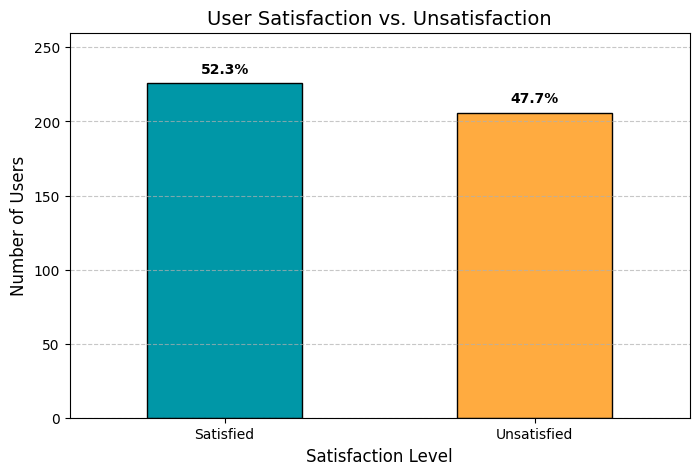

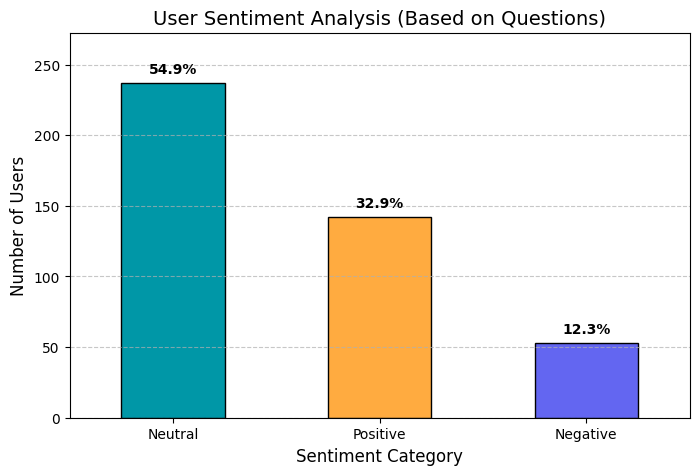

In [42]:
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

# ---------------------------------------------------------
# 1. Satisfaction vs Unsatisfaction Bar Chart
# ---------------------------------------------------------

# Define satisfaction: 4 or 5 stars = Satisfied, everything else = Unsatisfied
super_clean['satisfaction_label'] = super_clean['star_rating'].apply(
    lambda x: 'Satisfied' if x >= 4 else 'Unsatisfied'
)

# Count the occurrences
satisfaction_counts = super_clean['satisfaction_label'].value_counts()
total_users = satisfaction_counts.sum()

# Plot the Satisfaction chart
plt.figure(figsize=(8, 5))
ax = satisfaction_counts.plot(kind='bar', color=['#0097A7', '#FFAB40'], edgecolor='black')

# Add percentages above the bars
for p in ax.patches:
  percentage = f'{(p.get_height() / total_users) * 100:.1f}%'
  ax.annotate(percentage,
    (p.get_x() + p.get_width() / 2., p.get_height()),
    ha='center',
    va='bottom',
    xytext=(0, 5),
    textcoords='offset points',
    fontweight='bold')

plt.title('User Satisfaction vs. Unsatisfaction', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Extend the y-axis to prevent cutoff
plt.ylim(0, satisfaction_counts.max() * 1.15)
plt.savefig('satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------
# 2. Sentiment Analysis Bar Chart
# ---------------------------------------------------------

# Initialize VADER just in case it's not active in this scope
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if pd.isna(text) or str(text).strip() == '':
        return 0
    return analyzer.polarity_scores(str(text))['compound']

# Using standard VADER thresholds for positive/negative/neutral
def sentiment_category(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to the questions in super_clean
super_clean['sentiment_score'] = super_clean['question'].apply(get_sentiment)
super_clean['sentiment_label'] = super_clean['sentiment_score'].apply(sentiment_category)

# Count the occurrences
sentiment_counts = super_clean['sentiment_label'].value_counts()
total_sentiment = sentiment_counts.sum()

# Plot the Sentiment chart
plt.figure(figsize=(8, 5))
ax2 = sentiment_counts.plot(kind='bar', color=['#0097A7', '#FFAB40', '#6366F1'], edgecolor='black')

# Add percentages above the bars
for p in ax2.patches:
  percentage = f'{(p.get_height() / total_sentiment) * 100:.1f}%'
  ax2.annotate(percentage,
    (p.get_x() + p.get_width() / 2., p.get_height()),
    ha='center',
    va='bottom',
    xytext=(0, 5),
    textcoords='offset points',
    fontweight='bold')

plt.title('User Sentiment Analysis (Based on Questions)', fontsize=14)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Extend the y-axis to prevent cutoff
plt.ylim(0, sentiment_counts.max() * 1.15)

plt.savefig('sentiment.png', dpi=300, bbox_inches='tight')

plt.show()